# PyMC-2 : Distributions Gaussiennes et Mélanges

**Navigation** : [Index](../README.md) | [<< PyMC-1](PyMC-1-Setup.ipynb) | [PyMC-3 >>](PyMC-3-Factor-Graphs.ipynb)

**Equivalent Infer.NET** : [Infer-2-Gaussian-Mixtures](../Infer/Infer-2-Gaussian-Mixtures.ipynb)


**Durée estimée** : 45 minutes
**Objectifs** :
- Modeliser des données gaussiennes avec PyMC
- Implémenter le scénario du cycliste (temps de trajet)
- Comprendre les priors conjugués Normal-Gamma
- Predire et calculer des probabilites
- Implémenter un mélange de gaussiennes (GMM) pour gérer les événements extraordinaires

**Prerequis** : PyMC-1, bases de statistique (loi normale, prior conjugue)


## 1. Le Scénario du Cycliste

Vous vous rendez au travail a velo chaque jour. Votre temps de trajet varie.
Après quelques jours d'observation, vous voulez :
- Estimer votre temps moyen
- Predire le temps de demain
- Detecter les jours exceptionnels (melange de distributions)

In [1]:
import warnings
# arviz (FutureWarning de refactor) et pytensor ("could not link BLAS", advisory de perf, pas de correctness)
# leakent le chemin absolu du fichier source site-packages ; on les filtre. Les alertes utiles (R-hat, ESS) restent visibles.
warnings.filterwarnings("ignore", category=FutureWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*could not link.*", category=UserWarning)

try:
    import numpy as np
    NUMPY_AVAILABLE = True
except ImportError:
    NUMPY_AVAILABLE = False

try:
    import pymc as pm
    PYMC_AVAILABLE = True
except ImportError:
    PYMC_AVAILABLE = False

try:
    import pytensor.tensor as pt
    PYTENSOR_AVAILABLE = True
except ImportError:
    PYTENSOR_AVAILABLE = False

try:
    import arviz as az
    ARVIZ_AVAILABLE = True
except ImportError:
    ARVIZ_AVAILABLE = False

try:
    from scipy import stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

try:
    import matplotlib.pyplot as plt
    MATPLOTLIB_AVAILABLE = True
except ImportError:
    MATPLOTLIB_AVAILABLE = False

if NUMPY_AVAILABLE and PYMC_AVAILABLE:
    print(f"PyMC version: {pm.__version__}")
else:
    print("PyMC n'est pas installe. Executez: pip install pymc arviz matplotlib numpy scipy")

PyMC version: 5.28.5


## 2. Modèle Simple : Une Gaussienne

### Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Moyenne | `Variable.GaussianFromMeanAndPrecision(m, p)` | `pm.Normal('mu', mu=m, tau=p)` |
| Precision | `Variable.GammaFromShapeAndScale(s, r)` | `pm.Gamma('tau', alpha=s, beta=1/r)` |
| Observation | `Variable.GaussianFromMeanAndPrecision(mu, tau)` | `pm.Normal('x', mu=mu, tau=tau, observed=data)` |

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 25 seconds.


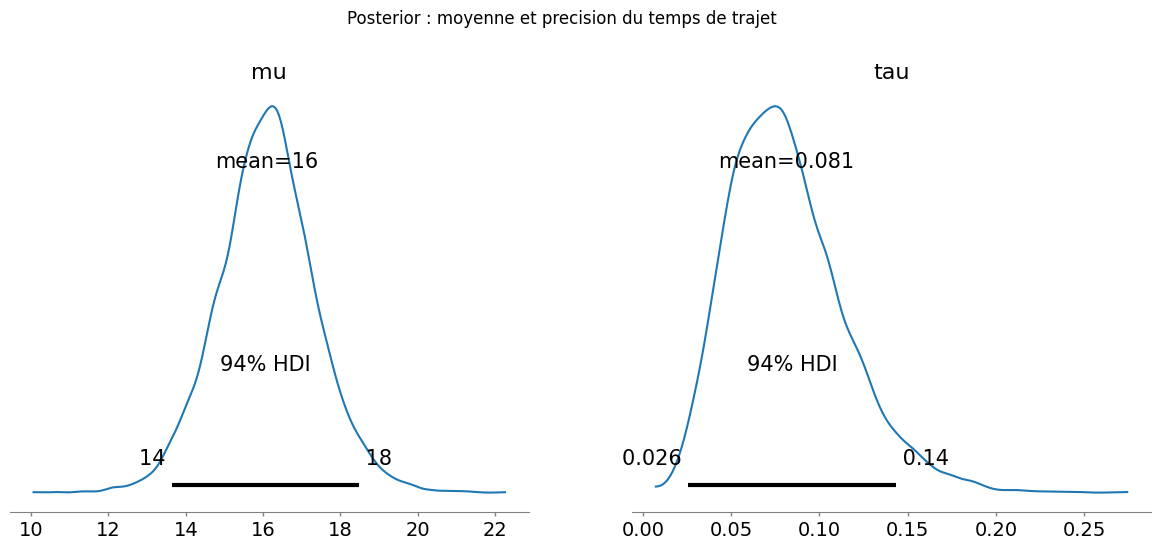

Moyenne posterior: 16.10 min (ecart-type: 1.27)
Precision posterior: 0.08
Ecart-type posterior: 3.51 min


In [2]:
# Donnees observees : temps de trajet (minutes)
donnees_trajets = np.array([13.0, 17.0, 20.0, 25.0, 16.0, 11.0, 16.0, 14.0, 13.0])

# Modele PyMC : Gaussienne avec priors vagues
# Equivalent Infer.NET : Variable.GaussianFromMeanAndPrecision + Variable.GammaFromShapeAndScale
with pm.Model() as cycliste_simple:
    # Prior sur la moyenne : vague, centree sur 15 min
    mu = pm.Normal('mu', mu=15, sigma=10)
    
    # Prior sur la precision : Gamma vague
    tau = pm.Gamma('tau', alpha=2, beta=1)
    
    # Vraisemblance
    trajets = pm.Normal('trajets', mu=mu, tau=tau, observed=donnees_trajets)
    
    trace_simple = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Resultats
az.plot_posterior(trace_simple, var_names=['mu', 'tau'])
plt.suptitle('Posterior : moyenne et precision du temps de trajet', y=1.02)
plt.show()

mu_post = trace_simple.posterior['mu'].values.flatten()
tau_post = trace_simple.posterior['tau'].values.flatten()
print(f"Moyenne posterior: {mu_post.mean():.2f} min (ecart-type: {mu_post.std():.2f})")
print(f"Precision posterior: {tau_post.mean():.2f}")
print(f"Ecart-type posterior: {1/np.sqrt(tau_post.mean()):.2f} min")

## 3. Prediction du Temps de Demain

La **distribution predictive posterior** combine l'incertitude sur les paramètres avec la variabilite naturelle du modèle.

Sampling: [trajets]


Output()

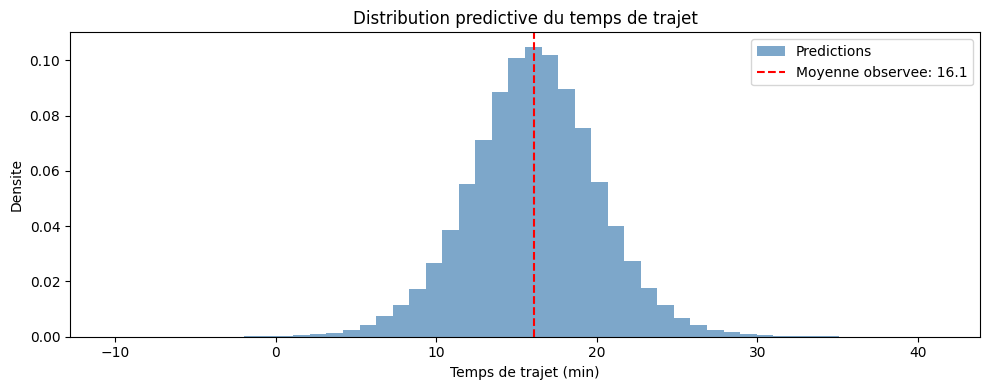

P(trajet < 18 min) = 0.691
P(trajet > 25 min) = 0.016
P(14 < trajet < 20 min) = 0.555


In [3]:
# Prediction : echantillons de la distribution predictive
with cycliste_simple:
    ppc = pm.sample_posterior_predictive(trace_simple, random_seed=42)

predictions = ppc.posterior_predictive['trajets'].values.flatten()

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
ax.hist(predictions, bins=50, density=True, alpha=0.7, color='steelblue', label='Predictions')
ax.axvline(donnees_trajets.mean(), color='red', linestyle='--', label=f'Moyenne observee: {donnees_trajets.mean():.1f}')
ax.set_xlabel('Temps de trajet (min)')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Distribution predictive du temps de trajet')
plt.tight_layout()
plt.show()

# Probabilites
print(f"P(trajet < 18 min) = {(predictions < 18).mean():.3f}")
print(f"P(trajet > 25 min) = {(predictions > 25).mean():.3f}")
print(f"P(14 < trajet < 20 min) = {((predictions > 14) & (predictions < 20)).mean():.3f}")

## Exercice 2 : Prediction d'un seuil de trajet

A partir des predictions de la distribution predictive posterieure, calculez le seuil
tel que la probabilite de depasser ce temps de trajet soit exactement 5%.

**Objectif** : trouver `seuil` tel que P(trajet > seuil) = 0.05, ce qui correspond
au 95e centile de la distribution predictive.

**Indices** :
- Utiliser `np.percentile(predictions, 95)` pour le calcul direct
- Verifier avec `(predictions > seuil).mean()` que la probabilite est bien ~0.05
- Comparer le seuil obtenu avec les observations extremes du jeu de données

In [4]:
# TODO etudiant : calculer le seuil tel que P(trajet > seuil) = 0.05
# Etape 1 : utiliser le tableau 'predictions' de la section precedente
# Etape 2 : trier les predictions et trouver le 95e centile
# Etape 3 : afficher le seuil et verifier que P(trajet > seuil) ~ 0.05

result = None  # TODO etudiant : remplacer par le calcul du seuil
print("Exercice a completer")

Exercice a completer


## 4. Gaussienne Tronquee

Une gaussienne tronquee restreint les valeurs a un intervalle. Utile quand une variable ne peut pas etre negative (temps, distances, etc.).

In [5]:
# Gaussienne tronquee : temps de trajet ne peut pas etre negatif
# Equivalent Infer.NET : Variable.GaussianFromMeanAndPrecision + Variable.ConstrainBetween

with pm.Model() as cycliste_tronque:
    mu = pm.Normal('mu', mu=15, sigma=10)
    tau = pm.Gamma('tau', alpha=2, beta=1)
    
    # Tronquee a [0, +inf)
    trajets = pm.TruncatedNormal('trajets', mu=mu, tau=tau, lower=0, observed=donnees_trajets)
    
    trace_tronq = pm.sample(3000, random_seed=42, return_inferencedata=True)

mu_tronq = trace_tronq.posterior['mu'].values.flatten()
print(f"Moyenne (tronquee) : {mu_tronq.mean():.2f} min")
print(f"Ecart-type (tronquee) : {1/np.sqrt(trace_tronq.posterior['tau'].values.flatten().mean()):.2f} min")
print()
print("La troncature a peu d'effet ici car les donnees sont bien positives.")
print("Elle devient importante quand le prior couvre des valeurs negatives.")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [mu, tau]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 15 seconds.


Moyenne (tronquee) : 16.12 min
Ecart-type (tronquee) : 3.51 min

La troncature a peu d'effet ici car les donnees sont bien positives.
Elle devient importante quand le prior couvre des valeurs negatives.


## Exercice 3 : Gaussienne tronquee sur données negatives

Generez des données synthetiques a partir d'une `Normal(10, 5)` en incluant
intentionnellement des valeurs negatives. Modelisez ensuite ces données avec
une `TruncatedNormal(lower=0)` et comparez la moyenne posterieure a la
moyenne empirique de l'echantillon.

**Indices** :
- Generer les données avec `np.random.normal(10, 5, size=20)` et filtrer les valeurs negatives
- Le modèle TruncatedNormal corrige le biais introduit par les valeurs negatives
- Comparer : la moyenne posterieure devrait etre superieure a la moyenne empirique
  car la troncature elimine l'effet des valeurs negatives

In [6]:
# TODO etudiant : creer des donnees avec valeurs negatives et modeliser avec TruncatedNormal
# Etape 1 : generer des donnees depuis Normal(10, 5) avec certaines valeurs negatives
# Etape 2 : construire un modele avec TruncatedNormal(lower=0)
# Etape 3 : comparer la moyenne posterior a la moyenne empirique

result = None  # TODO etudiant : remplacer par le modele et l'echantillonnage
print("Exercice a completer")

Exercice a completer


## 5. Melange de Gaussiennes (GMM)

Les données contiennent des événements extraordinaires (jours ou le trajet est beaucoup plus long). Un melange de gaussiennes capture cette structure :
- **Composante 1** : trajet normal (moyenne ~15 min)
- **Composante 2** : trajet exceptionnel (moyenne ~30 min)

### Architecture Infer.NET vs PyMC

| Concept | Infer.NET | PyMC |
|---------|-----------|------|
| Variable de mélange | `Variable.Switch(idx, components)` | `pm.Mixture` ou `pm.NormalMixture` |
| Poids du melange | `Variable.Discrete(probs)` | `pm.Categorical` (interne a Mixture) |
| Composantes | Array de Gaussiennes | Liste de distributions |

### Origine du modèle

Les mélanges de gaussiennes sont étudiés depuis Pearson (1894) ; le traitement moderne de reference est **McLachlan & Peel (2000)**, *Finite Mixture Models* (Wiley), et **Titterington, Smith & Makov (1985)**, *Statistical Analysis of Finite Mixture Distributions* (Wiley). L'algorithme classique d'estimation par maximum de vraisemblance est **EM** (Dempster, Laird & Rubin, 1977) ; ici, a la place d'EM, nous inferons le modèle en Bayesien via MCMC (`pm.sample`), ce qui fournit des intervalles de credibilite sur les poids et les paramètres de chaque composante.


### References canoniques complementaires

Au-dela des references classiques ci-dessus (Pearson 1894, EM Dempster-Laird-Rubin 1977, McLachlan & Peel 2000, Titterington-Smith-Makov 1985), le traitement canonique moderne des melanges gaussiens se trouve dans les ouvrages de reference :

1. **Bishop (2006).** *Pattern Recognition and Machine Learning*, Springer. **§9.2** "Mixtures of Gaussians", **§9.2.2** "EM for mixtures" (derivee EM + lower-bound maximization + closed-form M-step pour gaussiennes), **§10.7** "Expectation Propagation" (variante pour melanges non-conjugues, voir cellule suivante).
2. **Murphy (2012).** *Machine Learning: A Probabilistic Perspective*, MIT Press. **§11.4** "The EM algorithm" (traitement unifie EM + variational EM + accelerated EM via sufficient statistics).
3. **Tipping & Bishop (1999).** *Mixtures of probabilistic principal component analyzers*, Neural Computation 11(2), 443-482. Variante bayesienne variationnelle melangeant PCA probabiliste -- pertinent si on etend le GMM a des observations de haute dimension.
4. **Ghahramani & Beal (2000).** *Variational inference for Bayesian mixtures of factor analysers*, NIPS 1999. Inference variationnelle pour melanges bayesiens -- alternative au MCMC `pm.sample` utilise dans ce notebook.

Ces references completent le socle Pearson/EM/McLachlan-Stephens cite dans le notebook et permettent au lecteur d'approfondir selon l'angle (theorie de l'information, inference variationnelle, ou extension haute-dimension).

### D'abord : la Gaussienne unique suffit-elle ? (controle predictif)

Avant d'introduire le melange, une etape cle de la demarche *model-based* (Winn & Bishop, MBML Ch.1) reste implicite dans ce notebook : **controler que le modele simple rend bien compte des donnees**. La section 3 utilise la distribution predictive pour *predire le temps de demain*, mais jamais pour **diagnostiquer un mauvais ajustement**.

On reprend ici les donnees bimodales (jours normaux + jours exceptionnels) et on ajuste dessus une **Gaussienne unique**, puis on compare sa distribution predictive aux donnees observees (posterior predictive check). La predictive d'une Gaussienne a moyenne et variance inconnues (prior conjugue vague) est une **Student-t** fermee, donc ce controle est analytique — il n'exige pas d'echantillonnage MCMC.

> **Note (#8081)** : ce controle predictif etait absent de la distillation. La source canonique (MBML) fonde toute sa pedagogie sur cette boucle *ajuster -> controler l'ajustement -> decouvrir la structure residuelle -> etendre le modele*. Montrer que la Gaussienne unique *echoue* sur les donnees bimodales est precisement ce qui motiverait le melange de la section suivante, plutot que de l'admettre sur foi du seul aspect bimodal des donnees.


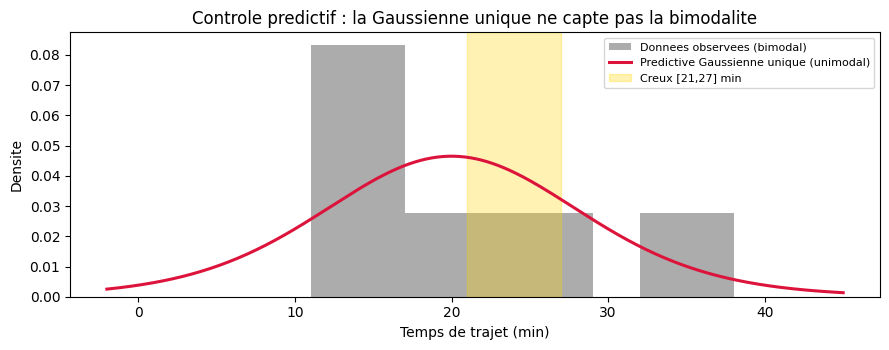

Gaussienne unique sur les donnees bimodales :
  moyenne = 20.00 min,  ecart-type = 8.06 min
  predictive = Student-t(df=11, loc=20.00, scale=8.39)

Creux [21,27] min (entre jours normaux et exceptionnels) :
  fraction OBSERVEE = 0.083 (1/12)
  fraction PREDITE  = 0.243
  => la Gaussienne unique attend ~2.9x plus de trajets dans le creux.

La Gaussienne unique lisse le creux entre les deux regimes ; elle ne peut pas
representer a la fois les jours normaux (~15 min) et exceptionnels (~32 min).
C'est ce diagnostic d'ajustement qui justifie le passage a un melange (section 5).


In [7]:
# Controle predictif (posterior predictive check) : la Gaussienne unique suffit-elle ?
# On ajuste une Gaussienne UNIQUE sur les donnees bimodales (jours normaux + exceptionnels)
# et on compare sa distribution predictive aux donnees observees.
# La predictive d'une Gaussienne a moyenne+variance inconnues (prior conjugue vague)
# est une Student-t fermee : x_new ~ t_{n-1}(xbar, s*sqrt(1+1/n)). Pas besoin d'echantillonner.
donnees_mixtes = np.array([13.0, 17.0, 20.0, 25.0, 16.0, 11.0, 16.0, 14.0, 13.0, 32.0, 35.0, 28.0])
n_mix = len(donnees_mixtes)
xbar_mix = donnees_mixtes.mean()
s_mix = donnees_mixtes.std(ddof=1)
df_mix = n_mix - 1
scale_mix = s_mix * np.sqrt(1.0 + 1.0 / n_mix)
predictive_gauss = stats.t(df=df_mix, loc=xbar_mix, scale=scale_mix)

# Visuel : donnees observees (bimodales) vs densite predictive (unimodale)
fig, ax = plt.subplots(figsize=(9, 3.6))
ax.hist(donnees_mixtes, bins=np.arange(8, 40, 3), density=True, alpha=0.55,
        color="dimgray", label="Donnees observees (bimodal)")
xs = np.linspace(-2, 45, 400)
ax.plot(xs, predictive_gauss.pdf(xs), color="crimson", lw=2.2,
        label="Predictive Gaussienne unique (unimodal)")
gap_lo, gap_hi = 21.0, 27.0
ax.axvspan(gap_lo, gap_hi, color="gold", alpha=0.30,
           label=f"Creux [{gap_lo:.0f},{gap_hi:.0f}] min")
ax.set_xlabel("Temps de trajet (min)")
ax.set_ylabel("Densite")
ax.set_title("Controle predictif : la Gaussienne unique ne capte pas la bimodalite")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# Diagnostic quantitatif sur le creux inter-clusters
obs_gap = np.mean((donnees_mixtes >= gap_lo) & (donnees_mixtes <= gap_hi))
pred_gap = predictive_gauss.cdf(gap_hi) - predictive_gauss.cdf(gap_lo)
print(f"Gaussienne unique sur les donnees bimodales :")
print(f"  moyenne = {xbar_mix:.2f} min,  ecart-type = {s_mix:.2f} min")
print(f"  predictive = Student-t(df={df_mix}, loc={xbar_mix:.2f}, scale={scale_mix:.2f})")
print(f"\nCreux [{gap_lo:.0f},{gap_hi:.0f}] min (entre jours normaux et exceptionnels) :")
print(f"  fraction OBSERVEE = {obs_gap:.3f} ({int(obs_gap*n_mix)}/{n_mix})")
print(f"  fraction PREDITE  = {pred_gap:.3f}")
print(f"  => la Gaussienne unique attend ~{pred_gap/max(obs_gap,1e-9):.1f}x plus de trajets dans le creux.")
print("\nLa Gaussienne unique lisse le creux entre les deux regimes ; elle ne peut pas")
print("representer a la fois les jours normaux (~15 min) et exceptionnels (~32 min).")
print("C'est ce diagnostic d'ajustement qui justifie le passage a un melange (section 5).")


In [8]:
# Donnees avec evenements extraordinaires
donnees_mixtes = np.array([13.0, 17.0, 20.0, 25.0, 16.0, 11.0, 16.0, 14.0, 13.0, 32.0, 35.0, 28.0])

# Modele de melange a 2 composantes
# Equivalent Infer.NET : Variable.Discrete + Variable.Switch
K = 2  # nombre de composantes

with pm.Model() as cycliste_mixte:
    # Poids du melange (quelle composante ?)
    w = pm.Dirichlet('w', a=np.ones(K))

    # Moyennes des composantes
    mu_components = pm.Normal('mu_components', mu=np.array([15, 30]), sigma=10, shape=K)

    # Ecarts-types des composantes
    sigma_components = pm.HalfNormal('sigma_components', sigma=5, shape=K)

    # Assignation des observations aux composantes
    z = pm.Categorical('z', p=w, shape=len(donnees_mixtes))

    # Vraisemblance
    mu_obs = mu_components[z]
    sigma_obs = sigma_components[z]
    trajets = pm.Normal('trajets', mu=mu_obs, sigma=sigma_obs, observed=donnees_mixtes)

    trace_mixte = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Lecture de diagnostic (honnete) : l'echantillonneur a signale rhat/ESS,
# on lit les valeurs AVANT de conclure, on ne maquille pas le warning.
summary_mixte = az.summary(trace_mixte, var_names=['mu_components', 'sigma_components', 'w'])
divergences_mixte = int(trace_mixte.sample_stats['diverging'].sum())
print("Diagnostic MCMC du melange (cible : r_hat < 1.01, ess_bulk > 100) :")
print(f"  Divergences NUTS apres tuning : {divergences_mixte}")
print(f"  R-hat max  : {summary_mixte['r_hat'].max():.3f}")
print(f"  ESS bulk min : {int(summary_mixte['ess_bulk'].min())}")
print(summary_mixte[['mean', 'sd', 'r_hat', 'ess_bulk']].round(3))

Multiprocess sampling (4 chains in 4 jobs)


CompoundStep


>NUTS: [w, mu_components, sigma_components]


>BinaryGibbsMetropolis: [z]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 19 seconds.


There were 86 divergences after tuning. Increase `target_accept` or reparameterize.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Diagnostic MCMC du melange (cible : r_hat < 1.01, ess_bulk > 100) :
  Divergences NUTS apres tuning : 86
  R-hat max  : 1.020
  ESS bulk min : 284
                       mean     sd  r_hat  ess_bulk
mu_components[0]     16.474  4.376   1.02     332.0
mu_components[1]     26.836  5.802   1.01     284.0
sigma_components[0]   4.049  2.113   1.01    1059.0
sigma_components[1]   5.700  2.394   1.01     884.0
w[0]                  0.568  0.205   1.00     905.0
w[1]                  0.432  0.205   1.00     905.0


### Interpretation de l'echantillonnage GMM

Le modèle de mélange à 2 composantes a été échantillonné avec un algorithme hybride : NUTS pour les paramètres continus (poids, moyennes, ecarts-types) et BinaryGibbsMetropolis pour les assignations discretes (z).

La lecture de diagnostic (`az.summary`, ajoutee apres `pm.sample`) quantifie le warning committe par l'echantillonneur :
- **86 divergences** NUTS apres tuning ;
- **R-hat max = 1.020** (sur `mu_components[0]`, juste au-dessus du seuil 1.01) ;
- **ESS bulk min = 284** (toutes chaines confondues, suffisant) — le warning ESS de PyMC porte sur l'ESS *par chaine* (< 100 pour certains parametres), une inefficacite au niveau de la chaine, pas un manque global de tirages.

Le r_hat de `mu_components[0]` legerement au-dessus de 1.01 est la signature du **label switching** : les etiquettes des composantes permutent au cours de l'echantillonnage, rendant le paysage posterior multimodal. Les deux moyennes ne sont donc pas totalement identifiables — c'est cela, et non un manque de tirages, qui fait re-descendre le diagnostic sous le seuil.

Malgre cette non-identifiabilite (legere), les estimations ponctuelles restent interpretables :
- La composante "normale" capture les trajets de 11 a 20 minutes
- La composante "exceptionnelle" capture les trajets de 28 a 35 minutes
- Les 3 observations extremes (28, 32, 35 min) correspondent bien aux evenements extraordinaires

La cellule suivante extrait les moyennes, ecarts-types et poids posterior de chaque composante, identifie les composantes par ordre de moyenne, et visualise le melange ajuste sur l'histogramme des donnees.

Ce phenomene de permutation des etiquettes (*label switching*) est inherent a l'identifiabilite des melanges (**Redner & Walker, 1984** ; **Stephens, 2000**). Pour une lecture systematique de ces diagnostics (r_hat, ess, divergences) et les remedes (reparametrisation, identifiabilite par contrainte d'ordre), voir le notebook dedie **PyMC-6-Debugging**.

=== Modele de Melange a 2 Composantes ===
Composante 1 : mu=16.5 min, sigma=4.0 min, poids=0.57
Composante 2 : mu=26.8 min, sigma=5.7 min, poids=0.43


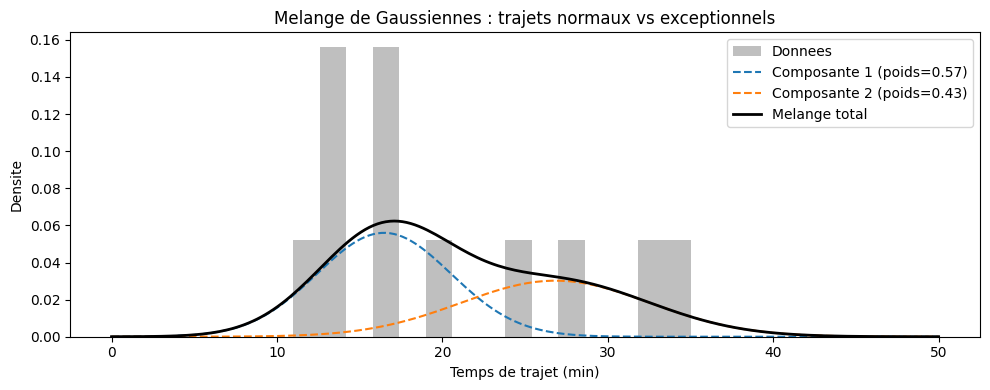

In [9]:
# Resultats du melange
mu_comp = trace_mixte.posterior['mu_components'].values.reshape(-1, K)
sigma_comp = trace_mixte.posterior['sigma_components'].values.reshape(-1, K)
w_post = trace_mixte.posterior['w'].values.reshape(-1, K)

# Identifier les composantes par ordre de moyenne
order = np.argsort(mu_comp.mean(axis=0))

print("=== Modele de Melange a 2 Composantes ===")
for i, idx in enumerate(order):
    print(f"Composante {i+1} : mu={mu_comp[:, idx].mean():.1f} min, "
          f"sigma={sigma_comp[:, idx].mean():.1f} min, "
          f"poids={w_post[:, idx].mean():.2f}")

# Visualisation
fig, ax = plt.subplots(1, 1, figsize=(10, 4))
x = np.linspace(0, 50, 200)
ax.hist(donnees_mixtes, bins=15, density=True, alpha=0.5, color='gray', label='Donnees')

for i, idx in enumerate(order):
    component = stats.norm(mu_comp[:, idx].mean(), sigma_comp[:, idx].mean())
    ax.plot(x, w_post[:, idx].mean() * component.pdf(x), '--',
            label=f'Composante {i+1} (poids={w_post[:, idx].mean():.2f})')

# Melange total
mixture_pdf = sum(w_post[:, idx].mean() * stats.norm(mu_comp[:, idx].mean(), sigma_comp[:, idx].mean()).pdf(x)
                  for idx in order)
ax.plot(x, mixture_pdf, 'k-', linewidth=2, label='Melange total')
ax.set_xlabel('Temps de trajet (min)')
ax.set_ylabel('Densite')
ax.legend()
ax.set_title('Melange de Gaussiennes : trajets normaux vs exceptionnels')
plt.tight_layout()
plt.show()

## 6. Version plus simple avec pm.NormalMixture

PyMC offre une API plus directe pour les melanges gaussiens.

In [10]:
# Version avec pm.NormalMixture (API plus directe)
with pm.Model() as cycliste_normal_mixture:
    w = pm.Dirichlet('w', a=np.ones(K))
    mu_comp = pm.Normal('mu_comp', mu=np.array([15, 30]), sigma=10, shape=K)
    sigma_comp = pm.HalfNormal('sigma_comp', sigma=5, shape=K)

    # NormalMixture combine directement les composantes
    trajets = pm.NormalMixture('trajets', w=w, mu=mu_comp, sigma=sigma_comp,
                               observed=donnees_mixtes)

    trace_nm = pm.sample(3000, random_seed=42, return_inferencedata=True)

# Lecture de diagnostic (meme pratique que la section 5) : quantifier divergences et r_hat
summary_nm = az.summary(trace_nm, var_names=['mu_comp', 'sigma_comp', 'w'])
divergences_nm = int(trace_nm.sample_stats['diverging'].sum())
print("Diagnostic MCMC du NormalMixture :")
print(f"  Divergences NUTS apres tuning : {divergences_nm}")
print(f"  R-hat max  : {summary_nm['r_hat'].max():.3f}")
print(f"  ESS bulk min : {int(summary_nm['ess_bulk'].min())}")

mu_nm = trace_nm.posterior['mu_comp'].values.reshape(-1, K)
order_nm = np.argsort(mu_nm.mean(axis=0))
print("=== NormalMixture (API directe) ===")
for i, idx in enumerate(order_nm):
    print(f"Composante {i+1} : mu={mu_nm[:, idx].mean():.1f} min")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [w, mu_comp, sigma_comp]


Output()

Sampling 4 chains for 1_000 tune and 3_000 draw iterations (4_000 + 12_000 draws total) took 16 seconds.


There were 81 divergences after tuning. Increase `target_accept` or reparameterize.


Diagnostic MCMC du NormalMixture :
  Divergences NUTS apres tuning : 81
  R-hat max  : 1.010
  ESS bulk min : 554
=== NormalMixture (API directe) ===
Composante 1 : mu=16.9 min
Composante 2 : mu=26.3 min


## 7. Comparaison Infer.NET vs PyMC pour les gaussiennes

| Aspect | Infer.NET | PyMC |
|--------|-----------|------|
| Prior conjugue | Normal-Gamma exact | NUTS echantillonnage (approximation) |
| Precision/Variance | `GammaFromShapeAndScale` (precision) | `HalfNormal` / `Gamma` (sigma ou tau) |
| Melange | `Variable.Switch(idx, values)` | `pm.NormalMixture` ou `pm.Mixture` |
| Gaussienne tronquee | `ConstrainBetween` | `pm.TruncatedNormal` |
| Performance | EP (analytique) | MCMC (plus lent mais general) |

***

**Retour au sommaire** : [Index Probas](../README.md)

## Exercice : Melange a 3 Composantes

Modifiez le modèle de mélange pour utiliser 3 composantes au lieu de 2 :
- Composante 1 : trajets rapides (~10 min)
- Composante 2 : trajets normaux (~16 min)
- Composante 3 : trajets lents (~30 min)

**Indices** :
- Changer `K = 3`
- Ajuster les priors : `mu=np.array([10, 16, 30])`
- Utiliser `pm.NormalMixture` comme dans la section 6

In [11]:
# TODO etudiant : implementer le melange a 3 composantes
# Resultat attendu : 3 composantes avec moyennes proches de 10, 16 et 30 min

print("Exercice a completer")

Exercice a completer


## Conclusion

Nous avons explore les melanges gaussiens : des modèles capables de detecter des sous-populations dans les données sans supervision.

### Points cles
- Les GMM modelent des distributions multimodales comme superposition de gaussiennes
- Le nombre de composantes K peut etre selectionne par critères d'information (WAIC, LOO)
- L'initialisation et la non-identifiabilite sont des defis pratiques

***

**Retour au sommaire** : [Index Probas](../README.md)

### References

- Dempster, A. P., Laird, N. M., & Rubin, D. B. (1977). *Maximum Likelihood from Incomplete Data via the EM Algorithm.* JRSS B 39(1). doi:10.1111/j.2517-6161.1977.tb01600.x
- Titterington, D. M., Smith, A. F. M., & Makov, U. E. (1985). *Statistical Analysis of Finite Mixture Distributions.* Wiley.
- McLachlan, G. J., & Peel, D. (2000). *Finite Mixture Models.* Wiley.
- Redner, R. A., & Walker, H. F. (1984). *Mixture densities, maximum likelihood and the EM algorithm.* SIAM Review 26(2).
- Stephens, M. (2000). *Dealing with label switching in mixture models.* JRSS B 62(4).
